## Hồi quy Logistic (Logistic Regression)

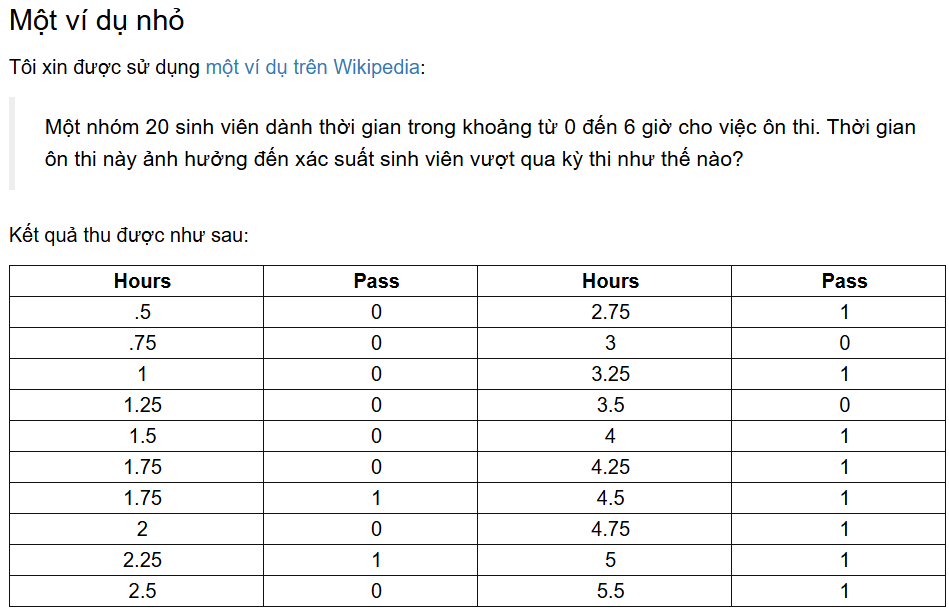

Mặc dù có một chút bất công khi học 3.5 giờ thì trượt, còn học 1.75 giờ thì lại đỗ, nhìn chung, học càng nhiều thì khả năng đỗ càng cao. PLA không thể áp dụng được cho bài toán này vì không thể nói một người học bao nhiêu giờ thì 100% trượt hay đỗ, và thực tế là dữ liệu này cũng không linearly separable (điệu kiện để PLA có thể làm việc). Chú ý rằng các điểm màu đỏ và xanh được vẽ ở hai tung độ khác nhau để tiện cho việc minh họa. Các điểm này được vẽ dùng cả dữ liệu đầu vào 
x
 và đầu ra \(y). Khi ta nói linearly seperable là khi ta chỉ dùng dữ liệu đầu vào 
x
.

Chúng ta biểu diễn các điểm này trên đồ thị để thấy rõ hơn:

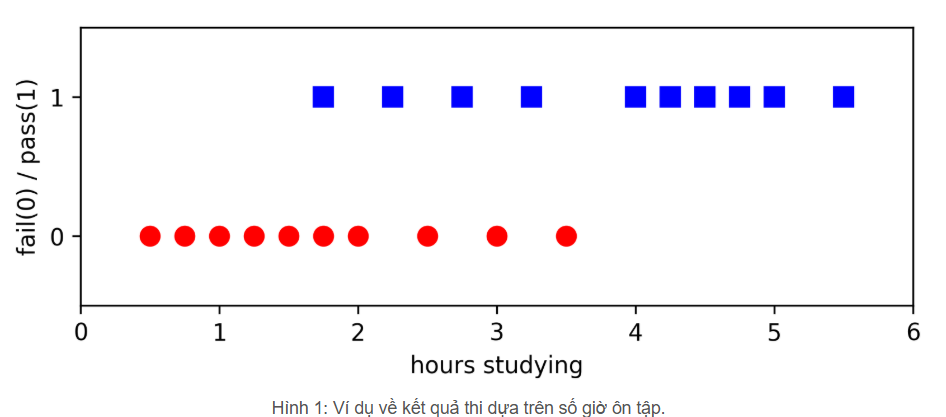

Nhận thấy rằng cả linear regression và PLA đều không phù hợp với bài toán này, chúng ta cần một mô hình flexible hơn.

## Mô hình Logistic Regression

Đầu ra dự đoán của các mô hình:

* **Linear Regression:** $f(x) = w^T x$
* **PLA:** $f(x) = \text{sgn}(w^T x)$
* **Logistic Regression:** Đầu ra dự đoán thường được viết chung dưới dạng: $f(x) = \theta(w^T x)$

Trong đó $\theta$ được gọi là **logistic function**. Một số activation (hàm kích hoạt) cho mô hình tuyến tính được cho trong hình dưới đây:

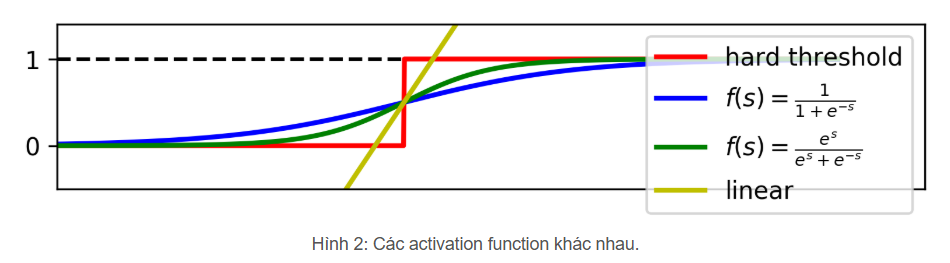

### Linear Regression thất bại trong bài toán phân loại

1. **Vấn đề về giới hạn:** Đường màu vàng (Linear Regression) là một đường thẳng kéo dài vô tận, không bị chặn đầu chặn đuôi. Trong khi đó, xác suất hay nhãn phân loại của chúng ta chỉ nằm trong khoảng từ 0 đến 1. 

2. **Cách tiếp cận "cắt ngọn" (Hard Thresholding):** Một mẹo nhỏ là ép các giá trị nhỏ hơn 0 về 0 và lớn hơn 1 về 1, sau đó lấy mốc 0.5 làm ranh giới chia lớp. Tuy nhiên, đây vẫn là một lựa chọn tồi.

3. **Hiện tượng "Sinh viên tiêu biểu" phá hỏng mô hình:** * Hãy tưởng tượng có một vài sinh viên cực kỳ chăm chỉ, ôn tập tới 20 giờ và chắc chắn thi đỗ. 
    * Khi thêm những điểm dữ liệu "cực đoan" này vào, đường thẳng Linear Regression sẽ bị **kéo lệch** hẳn sang một bên để giảm thiểu sai số.
    * Kết quả là ngưỡng phân loại 0.5 bị đẩy đi quá xa. Lúc này, dù nhiều bạn khác có học đủ để đỗ, nhưng vì "anh chàng tiêu biểu" kia kéo cái ngưỡng lên quá cao, mô hình vẫn sẽ dự đoán các bạn đó bị trượt.

**Kết luận:** Linear Regression quá nhạy cảm với các điểm dữ liệu xa (outliers), dẫn đến việc phân lớp không còn chính xác. Đó là lý do chúng ta cần một đường cong "mềm dẻo" hơn như **Logistic Regression**.

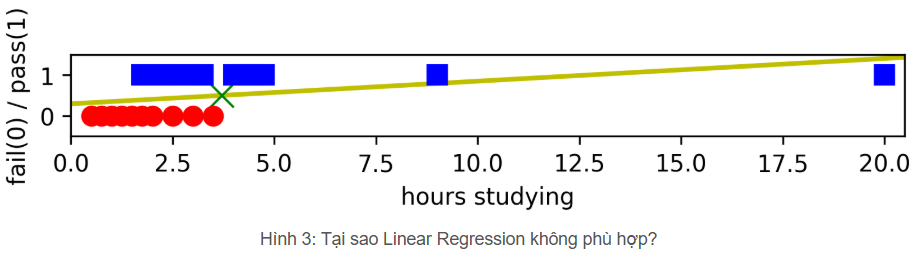

### Đường màu xanh (Sigmoid) "ăn đứt" đường màu đỏ (PLA)

1. **Vấn đề của đường màu đỏ (PLA/Hard Threshold):** Nhìn đường màu đỏ, nó cũng giống PLA nhưng thay vì nhãn -1 và 1 thì ở đây dùng 0 và 1. Tuy nhiên, PLA "bó tay" trong bài toán này vì dữ liệu thực tế không bao giờ tách biệt hoàn hảo (**not linearly separable**). Nó quá cứng nhắc, chỉ có "đỗ" hoặc "trượt" ngay lập tức, không có khoảng chuyển tiếp.

2. **Sự lợi hại của đường màu xanh lam và xanh lục:**
   Thay vì dùng cái ngưỡng cứng ngắc, hai đường này (đặc biệt là Sigmoid) tỏ ra "tâm lý" hơn nhiều với các đặc điểm:
   * **Bị chặn trong khoảng (0, 1):** Rất hợp lý vì chúng ta đang nói về xác suất. Không ai có xác suất đỗ là 150% hay -20% cả.
   * **Càng xa càng rõ ràng:** Nếu lấy mốc 0.5 làm chuẩn, bạn càng học ít (về bên trái) thì xác suất đỗ càng tiến sát về 0. Ngược lại, càng cày cuốc (về bên phải) thì xác suất đỗ càng tiến gần đến 1. Điều này cực kỳ sát với thực tế: học càng nhiều, khả năng đỗ càng cao.
   * **Độ mượt (Smoothness):** Vì nó là đường cong liên tục, có đạo hàm tại mọi điểm nên việc dùng các thuật toán tối ưu (như Gradient Descent) để tìm tham số sẽ "dễ thở" hơn nhiều so với các hàm đứt đoạn.

**Tóm lại:** Thay vì bắt mô hình trả lời "Đỗ" hay "Trượt" một cách cực đoan, chúng ta để nó dự đoán "Xác suất đỗ là bao nhiêu". Đó chính là linh hồn của Logistic Regression.

## Sigmoid function

Trong "họ hàng" các hàm kích hoạt, **Sigmoid** ($\sigma$) là lựa chọn số 1 vì 3 lý do "vàng":

1. **Đúng bản chất xác suất:** Nó nén mọi giá trị về khoảng $(0, 1)$. Càng học ít thì $\sigma \to 0$, càng học nhiều thì $\sigma \to 1$. Quá hợp lý!
2. **Đạo hàm "siêu đẹp":** $$\sigma'(s) = \sigma(s)(1 - \sigma(s))$$
   *Cái này cực quan trọng: Chỉ cần lấy kết quả cũ nhân chia tí là ra đạo hàm, giúp máy tính chạy nhanh hơn hẳn khi huấn luyện.*
3. **Mượt mà:** Nó liên tục và có đạo hàm tại mọi điểm, không bị "gãy" như mấy hàm ngưỡng cứng (PLA).


### Ngoài ra, hàm tanh cũng hay được sử dụng:
Hàm **tanh** cũng hay được dùng, nhưng nó chạy từ $(-1, 1)$. Thực ra nó cũng chỉ là "anh em song sinh" với Sigmoid thôi, vì ta có thể biến đổi qua lại:
$$\text{tanh}(s) = 2\sigma(2s) - 1$$

 Sigmoid được dùng nhiều nhất đơn giản vì nó vừa **dễ tính toán** vừa **khớp với thực tế**.

## 2. Hàm mất mát và phương pháp tối ưu

#### Xây dựng hàm mất mát
Thay vì dùng sai số bình phương, Logistic Regression dùng xác suất để đánh giá. Ta có:
* Xác suất rơi vào class 1: $P(y_i=1|x_i; w) = f(w^T x_i) = z_i$
* Xác suất rơi vào class 0: $P(y_i=0|x_i; w) = 1 - z_i$

Để gộp hai biểu thức này lại cho gọn nhằm mục đích tính toán, ta dùng công thức:
$$P(y_i|x_i; w) = z_i^{y_i}(1-z_i)^{1-y_i}$$

**Giải thích:** Khi $y_i=1$, phần sau triệt tiêu. Khi $y_i=0$, phần đầu triệt tiêu. Cách viết gộp này giúp chúng ta tính toán trên toàn bộ tập dữ liệu dễ dàng hơn.

#### Bài toán Maximum Likelihood Estimation (MLE)
Mục tiêu là tìm $w$ sao cho mô hình khớp với dữ liệu thực tế nhất, tức là xác suất xảy ra toàn bộ tập training phải đạt giá trị lớn nhất. Giả sử các điểm dữ liệu độc lập, ta có hàm **Likelihood** (tích xác suất):
$$P(y|X; w) = \prod_{i=1}^{N} P(y_i|x_i; w) = \prod_{i=1}^{N} z_i^{y_i}(1-z_i)^{1-y_i}$$

#### Hàm mất mát Cross Entropy
Việc tính toán trực tiếp cái tích ($\prod$) kia rất khó vì dễ gây sai số máy tính khi số quá nhỏ. Vì vậy, ta dùng chiêu lấy Logarit tự nhiên ($\ln$) để biến phép nhân thành phép cộng, sau đó đổi dấu để chuyển từ bài toán tìm cực đại sang tìm cực tiểu (minimization). 

Hàm mất mát cuối cùng có tên gọi là **Cross Entropy**:
$$J(w) = -\log P(y|X; w) = -\sum_{i=1}^{N} [y_i \log z_i + (1 - y_i) \log(1 - z_i)]$$

**Bản chất:** Hàm này đo "khoảng cách" giữa dữ liệu thật và dự đoán của mô hình. Khoảng cách càng nhỏ (Min $J(w)$) thì mô hình càng chính xác. Đặc biệt, nó phạt rất nặng những trường hợp dự đoán sai lệch hoàn toàn, giúp mô hình học nhanh hơn.

## 3. Tối ưu hàm mất mát 

Để tìm $w$, dùng quen thuộc: **Stochastic Gradient Descent (SGD)**. 

Xét hàm mất mát tại một điểm dữ liệu:
$$J(w; x_i, y_i) = -(y_i \log z_i + (1 - y_i) \log(1 - z_i))$$

Khi tính đạo hàm để update trọng số, ta có:
$$\frac{\partial J}{\partial w} = \frac{z_i - y_i}{z_i(1 - z_i)} \frac{\partial z_i}{\partial w}$$

#### Nguồn gốc hàm Sigmoid
Nhìn cái mẫu số $z_i(1 - z_i)$ trông rất vướng mắt. Để biểu thức đẹp và gọn nhất, các nhà toán học đã đặt ra một câu hỏi: **"Liệu có hàm $z = f(s)$ nào mà đạo hàm của nó triệt tiêu luôn cái mẫu số kia không?"**

Tức là ta cần tìm hàm $z$ sao cho:
$$\frac{\partial z}{\partial s} = z(1 - z)$$

Giải phương trình vi phân này (bằng cách chia vế và lấy nguyên hàm), ta có:
1. $\int \frac{1}{z(1-z)} dz = \int ds$
2. $\ln \frac{z}{1-z} = s$
3. Kết quả cuối cùng: $$z = \frac{1}{1 + e^{-s}} = \sigma(s)$$

 hàm Sigmoid giúp đạo hàm của hàm mất mát trở nên **siêu gọn**:
$$\frac{\partial J}{\partial w} = (z_i - y_i)x_i$$

**Kết luận:** Nhờ Sigmoid, việc cập nhật $w$ chỉ đơn giản là lấy (Dự đoán - Thực tế) rồi nhân với dữ liệu đầu vào. Vừa nhanh, vừa đẹp, vừa đỡ tốn tài nguyên máy tính!

## Công thức cập nhật (SGD) cực gọn

Sau khi triệt tiêu các thành phần phức tạp nhờ hàm Sigmoid, đạo hàm của hàm mất mát:
$$\frac{\partial J(w; x_i, y_i)}{\partial w} = (z_i - y_i)x_i$$

Từ đó, công thức cập nhật trọng số theo thuật toán **SGD** cho Logistic Regression đơn giản là:
$$w = w + \eta(y_i - z_i)x_i$$

**Trong đó:**
* $\eta$: Learning rate (tốc độ học).
* $(y_i - z_i)$: Sai số giữa nhãn thực tế và dự đoán.
* $x_i$: Dữ liệu đầu vào.

**Nhận xét:** Công thức này giống công thức của Linear Regression và Perceptron, nhưng bản chất $z_i$ ở đây là xác suất. Quá đẹp và dễ cài đặt! 

Dưới đây là vài ví dụ triển khai bằng **Python** để kiểm chứng sức mạnh của mô hình này.

## Ví dụ với Python
#### Ví dụ với dữ liệu 1 chiều:


Quay trở lại với ví dụ nêu ở phần Giới thiệu. Trước tiên ta cần khai báo vài thư viện và dữ liệu:

In [4]:
# To support both python 2 and python 3
from __future__ import division, print_function, unicode_literals
import numpy as np 
import matplotlib.pyplot as plt
np.random.seed(2)

X = np.array([[0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50, 
              2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50]])
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

# extended data 
X = np.concatenate((np.ones((1, X.shape[1])), X), axis = 0)

### Các hàm cần thiết cho logistic sigmoid regression

In [6]:
def sigmoid(s):
    return 1/(1 + np.exp(-s))

def logistic_sigmoid_regression(X, y, w_init, eta, tol = 1e-4, max_count = 10000):
    w = [w_init]    
    it = 0
    N = X.shape[1]
    d = X.shape[0]
    count = 0
    check_w_after = 20
    while count < max_count:
        # mix data 
        mix_id = np.random.permutation(N)
        for i in mix_id:
            xi = X[:, i].reshape(d, 1)
            yi = y[i]
            zi = sigmoid(np.dot(w[-1].T, xi))
            w_new = w[-1] + eta*(yi - zi)*xi
            count += 1
            # stopping criteria
            if count%check_w_after == 0:                
                if np.linalg.norm(w_new - w[-check_w_after]) < tol:
                    return w
            w.append(w_new)
    return w
eta = .05 
d = X.shape[0]
w_init = np.random.randn(d, 1)

w = logistic_sigmoid_regression(X, y, w_init, eta)
print(w[-1])
print(sigmoid(np.dot(w[-1].T, X)))

[[-4.08175132]
 [ 1.59767816]]
[[0.03616207 0.05297564 0.07698228 0.11059738 0.15640363 0.21656209
  0.21656209 0.29185433 0.38060633 0.47812499 0.57734009 0.67068463
  0.75226009 0.81907932 0.9096165  0.93751937 0.95721336 0.9708925
  0.9802884  0.9910355 ]]


### Biểu diễn kết quả này trên đồ thị ta có:



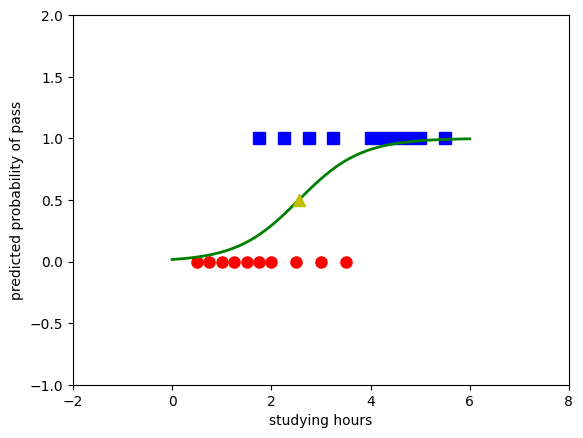

In [7]:
X0 = X[1, np.where(y == 0)][0]
y0 = y[np.where(y == 0)]
X1 = X[1, np.where(y == 1)][0]
y1 = y[np.where(y == 1)]

plt.plot(X0, y0, 'ro', markersize = 8)
plt.plot(X1, y1, 'bs', markersize = 8)

xx = np.linspace(0, 6, 1000)
w0 = w[-1][0][0]
w1 = w[-1][1][0]
threshold = -w0/w1
yy = sigmoid(w0 + w1*xx)
plt.axis([-2, 8, -1, 2])
plt.plot(xx, yy, 'g-', linewidth = 2)
plt.plot(threshold, .5, 'y^', markersize = 8)
plt.xlabel('studying hours')
plt.ylabel('predicted probability of pass')
plt.show()

### 4. Một vài tính chất của Logistic Regression

#### Tại sao tên là Regression nhưng lại dùng để Classification?
Dù có chữ "Regression" (hồi quy) trong tên gọi, nhưng Logistic Regression lại là "ông vua" trong các bài toán phân loại (**Classification**). 
* Sau khi huấn luyện, ta có xác suất $P(y=1|x; w)$.
* Ta chỉ cần so sánh: Nếu $P(y=1|x; w) > 0.5$ thì kết luận là **Class 1**, ngược lại là **Class 0**.

#### Đường biên phân chia (Boundary) là đường thẳng
Một điểm thú vị là dù chúng ta dùng hàm Sigmoid cong vút, nhưng ranh giới để phân chia hai lớp vẫn là **tuyến tính** (đường thẳng hoặc siêu mặt phẳng). 

Ta có thể chứng minh nhanh:
$$P(y=1|x; w) > 0.5$$
$$\Leftrightarrow \frac{1}{1 + e^{-w^T x}} > 0.5$$
$$\Leftrightarrow e^{-w^T x} < 1$$
$$\Leftrightarrow w^T x > 0$$

**Kết luận:** Ranh giới phân chia chính là phương trình $w^T x = 0$. Đây là một siêu mặt phẳng (hyperplane). Vì vậy, Logistic Regression về bản chất vẫn là một bộ phân loại tuyến tính nhưng ở mức độ "thông minh" và linh hoạt hơn PLA.